# Simple Chatbot with LangGraph and LLM (Streaming will be start after Building the LangGraph heading)

Build a simple chatbot using LangGraph and an LLM that can receive user messages, maintain them as graph state, process the messages through a chatbot node, and generate AI-powered responses. The chatbot should also demonstrate graph visualization, message reducers, graph invocation, and response streaming using different streaming modes.

## Importing Required Libraries

### LangGraph State and Reducer Imports

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

### Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

### Environment Variable Setup

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

### Importing ChatOpenAI

In [ ]:
from langchain_openai import ChatOpenAI

llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

### Importing ChatGroq

In [3]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="openai/gpt-oss-120b")
llm_groq.invoke("Hey, I am Dev and I am a big fan of Iron Man.")

AIMessage(content='Hey Dev! That’s awesome—Iron\u202fMan has such a cool blend of tech, wit, and style. Who’s your favorite version of Tony Stark (the classic MCU movies, the comics, the animated series, etc.)? Any particular suit or moment that really stands out for you? 🚀🦾✨', additional_kwargs={'reasoning_content': 'The user says: "Hey, I am Dev and I am a big fan of Iron\xa0Man." Probably wants a response. There\'s no request for disallowed content. So we can respond friendly. Possibly ask about Iron Man preferences. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 126, 'prompt_tokens': 86, 'total_tokens': 212, 'completion_time': 0.265430541, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.004214231, 'prompt_tokens_details': None, 'queue_time': 0.39481028, 'total_time': 0.269644772}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'm

## Creating the State Schema Using Annotated with add_messages

In [4]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

## Creating the Chatbot Node

In [5]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

## Building the LangGraph

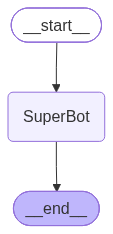

In [6]:
### Creating the Graph
graph=StateGraph(State)

### Adding the Node
graph.add_node("SuperBot", superbot)

### Adding Graph Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

### Compiling the Graph
graph_builder=graph.compile(checkpointer=memory)

### Displaying the Graph
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

## Invoking the Chatbot

### Passing Messages to the Graph with configuration

In [8]:
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages":"Hi, My name is Dev. I am big fan of Iron Man"}, config)

{'messages': [HumanMessage(content='Hi, My name is Dev. I am big fan of Iron Man', additional_kwargs={}, response_metadata={}, id='b85e9ddd-d9db-4fdd-9559-97b9a3cbc792'),
  AIMessage(content='Hey Dev! Great to meet a fellow Iron\u202fMan fan. 🚀  \nWhat’s your favorite Tony Stark moment? The “I am Iron Man” reveal, the first suit-up in the cave, or maybe one of the later movies? I’m curious—do you have a favorite comic run or a particular piece of tech from the Marvel universe that you wish were real?', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says hi, introduces themselves as Dev, fan of Iron\xa0Man. We can respond friendly, ask about their interest, maybe talk about Iron Man, ask about favorite movies, etc. No policy issues. Should be a normal friendly conversation.'}, response_metadata={'token_usage': {'completion_tokens': 144, 'prompt_tokens': 85, 'total_tokens': 229, 'completion_time': 0.300367517, 'completion_tokens_details': {'reasoning_tok

# Streaming the Chatbot Responses

Methods: **stream()** and **astream()**

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.
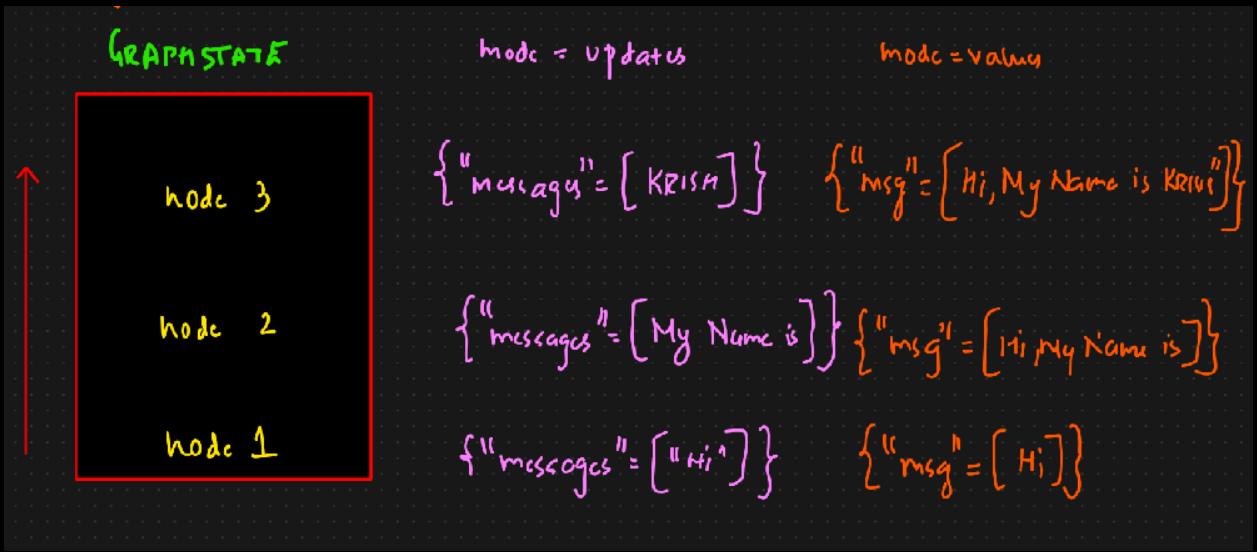

## Streaming the Responses with stream() method

### Streaming with stream_mode="updates"

In [12]:
config = {"configurable": {"thread_id": "2"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is Dev. I am big fan of Iron Man"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Dev! 👋 Great to meet a fellow Iron\u202fMan fan. Tony Stark’s blend of genius engineering, snappy one‑liners, and that iconic red‑gold armor never gets old.\n\nDo you have a favorite suit (the classic Mark\u202fIII, the sleek Mark\u202fL, the nanotech Mark\u202f50, etc.) or a standout movie/comic moment that always gets you pumped? If you ever want to geek out about the arc‑reactor, the AI behind JARVIS/FRIDAY, or even brainstorm some real‑world tech inspired by Stark’s inventions, just let me know! 🚀🦾', additional_kwargs={'reasoning_content': 'The user repeats same message. Likely wants a response. We can ask about preferences, talk about Iron Man. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 339, 'total_tokens': 504, 'completion_time': 0.352505964, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.017850235, 'prompt_tokens_details': None, 'queue_time': 0.34661369

### Streaming with stream_mode="values"

In [13]:
for chunk in graph_builder.stream({"messages":"Hi, My name is Dev. I am big fan of Iron Man"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Dev. I am big fan of Iron Man', additional_kwargs={}, response_metadata={}, id='0e653877-3fc3-4158-8848-890ce2435e84'), AIMessage(content='Hey Dev! 👋 Great to meet a fellow Iron\u202fMan fan. Tony Stark’s tech, wit, and charisma make him a legend—what’s your favorite suit or moment from the movies (or comics)? If you ever want to chat about the tech behind the arc reactor, the evolution of the suits, or anything else, I’m all ears! 🚀🦾', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Dev. I am big fan of Iron\xa0Man". There\'s no request, just greeting and statement. We should respond friendly, maybe ask about Iron Man, mention something. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 85, 'total_tokens': 220, 'completion_time': 0.28627673, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.004148488, 'prompt_tokens_details': None, 'queue_ti

### Streaming a Follow-up Message with stream_mode="updates"

In [14]:
for chunk in graph_builder.stream({"messages":"I am also a big fan of Spider Man"}, config, stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='That’s awesome, Dev! 🎉 Being a fan of both Iron\u202fMan and Spider‑Man gives you a front‑row seat to some of the best mentor‑student dynamics in the Marvel universe.\n\n### Quick “Marvel‑Mashup” Highlights\n| Topic | Iron\u202fMan | Spider‑Man |\n|-------|----------|------------|\n| **First cinematic appearance** | *Iron Man* (2008) – the movie that launched the MCU | *Spider‑Man* (2002) – Sam Raimi’s debut (or *Captain America:\u202fCivil War* 2016 for MCU) |\n| **Signature tech** | Arc‑reactor, nanotech suits, JARVIS/FRIDAY | Web‑shooters, spider‑sense, suit upgrades (e.g., Stark‑built suits in *Infinity War* and *No Way Home*) |\n| **Iconic line** | “I am Iron\u202fMan.” | “With great power comes great responsibility.” |\n| **Best team‑up** | *Avengers* (especially *Endgame*) | *Spider‑Man:\u202fHomecoming* (Stark‑Mentor), *Avengers:\u202fInfinity War* (the “snap” fight), *Spider‑Man:\u202fNo Way Home* (multiverse crossover) |\n\n### A 

### Streaming a Follow-up Message with stream_mode="values"

In [15]:
for chunk in graph_builder.stream({"messages":"I am also a big fan of Spider Man"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Dev. I am big fan of Iron Man', additional_kwargs={}, response_metadata={}, id='0e653877-3fc3-4158-8848-890ce2435e84'), AIMessage(content='Hey Dev! 👋 Great to meet a fellow Iron\u202fMan fan. Tony Stark’s tech, wit, and charisma make him a legend—what’s your favorite suit or moment from the movies (or comics)? If you ever want to chat about the tech behind the arc reactor, the evolution of the suits, or anything else, I’m all ears! 🚀🦾', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Dev. I am big fan of Iron\xa0Man". There\'s no request, just greeting and statement. We should respond friendly, maybe ask about Iron Man, mention something. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 85, 'total_tokens': 220, 'completion_time': 0.28627673, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.004148488, 'prompt_tokens_details': None, 'queue_ti

## Streaming the Responses with astream() method

We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- **event**: This is the type of event that is being emitted.
- **name**: This is the name of event.
- **data**: This is the data associated with the event.
- **metadata**: Containslanggraph_node, the node emitting the event.

### Streaming Events with astream_events()

In [16]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi, My name is Dev. I am big fan of Iron Man"]}, config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, My name is Dev. I am big fan of Iron Man']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0f31f-5316-7392-abf5-64d34e774184', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is Dev. I am big fan of Iron Man', additional_kwargs={}, response_metadata={}, id='8b5da0eb-3298-4fd3-b6f9-f6ef6922b50e')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0f31f-538f-7243-8c11-19742593ddd6', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:d6db90fc-bdeb-350d-fad9-70d2048315f4'}, 'parent_ids': ['01a0f31f-5316-7392-abf5-64d34e774184']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[H

**This hierarchy is cleaner** because `stream()` and `astream_events()` are the two actual streaming approaches, while `updates` and `values` are their respective streaming modes/examples.